In [2]:
import matplotlib.pyplot as plt
import numpy as np
import json

from fovmap import CONFIG_PATH

In [3]:
cone_config = json.load(open(CONFIG_PATH / "cone_config.json"))

In [ ]:
panorama_height = 240
real_y_position = np.arange(0, panorama_height, 1)/panorama_height*cone_config["height_cutoff"]*np.tan(np.deg2rad(cone_config["cone_angle_deg"]))
real_y_position

array([ 0.        ,  0.15701521,  0.31403043,  0.47104564,  0.62806085,
        0.78507606,  0.94209128,  1.09910649,  1.2561217 ,  1.41313692,
        1.57015213,  1.72716734,  1.88418255,  2.04119777,  2.19821298,
        2.35522819,  2.51224341,  2.66925862,  2.82627383,  2.98328905,
        3.14030426,  3.29731947,  3.45433468,  3.6113499 ,  3.76836511,
        3.92538032,  4.08239554,  4.23941075,  4.39642596,  4.55344117,
        4.71045639,  4.8674716 ,  5.02448681,  5.18150203,  5.33851724,
        5.49553245,  5.65254766,  5.80956288,  5.96657809,  6.1235933 ,
        6.28060852,  6.43762373,  6.59463894,  6.75165416,  6.90866937,
        7.06568458,  7.22269979,  7.37971501,  7.53673022,  7.69374543,
        7.85076065,  8.00777586,  8.16479107,  8.32180628,  8.4788215 ,
        8.63583671,  8.79285192,  8.94986714,  9.10688235,  9.26389756,
        9.42091277,  9.57792799,  9.7349432 ,  9.89195841, 10.04897363,
       10.20598884, 10.36300405, 10.52001926, 10.67703448, 10.83

In [6]:
z = cone_config["height_cutoff"] * (1  - real_y_position / real_y_position[-1])
z 

array([33.        , 32.86192469, 32.72384937, 32.58577406, 32.44769874,
       32.30962343, 32.17154812, 32.0334728 , 31.89539749, 31.75732218,
       31.61924686, 31.48117155, 31.34309623, 31.20502092, 31.06694561,
       30.92887029, 30.79079498, 30.65271967, 30.51464435, 30.37656904,
       30.23849372, 30.10041841, 29.9623431 , 29.82426778, 29.68619247,
       29.54811715, 29.41004184, 29.27196653, 29.13389121, 28.9958159 ,
       28.85774059, 28.71966527, 28.58158996, 28.44351464, 28.30543933,
       28.16736402, 28.0292887 , 27.89121339, 27.75313808, 27.61506276,
       27.47698745, 27.33891213, 27.20083682, 27.06276151, 26.92468619,
       26.78661088, 26.64853556, 26.51046025, 26.37238494, 26.23430962,
       26.09623431, 25.958159  , 25.82008368, 25.68200837, 25.54393305,
       25.40585774, 25.26778243, 25.12970711, 24.9916318 , 24.85355649,
       24.71548117, 24.57740586, 24.43933054, 24.30125523, 24.16317992,
       24.0251046 , 23.88702929, 23.74895397, 23.61087866, 23.47

In [7]:
theta = np.arctan(z / (cone_config["radius"] - (real_y_position[-1] - real_y_position)))
theta

array([1.17056015, 1.16501287, 1.15944542, 1.15385805, 1.148251  ,
       1.14262452, 1.13697886, 1.13131429, 1.12563108, 1.1199295 ,
       1.11420985, 1.1084724 , 1.10271745, 1.09694532, 1.0911563 ,
       1.08535071, 1.07952888, 1.07369113, 1.0678378 , 1.06196922,
       1.05608575, 1.05018773, 1.04427552, 1.03834949, 1.03241001,
       1.02645744, 1.02049218, 1.0145146 , 1.00852509, 1.00252406,
       0.9965119 , 0.99048901, 0.98445581, 0.9784127 , 0.97236011,
       0.96629846, 0.96022818, 0.95414969, 0.94806343, 0.94196983,
       0.93586934, 0.9297624 , 0.92364945, 0.91753094, 0.91140733,
       0.90527907, 0.8991466 , 0.8930104 , 0.88687092, 0.88072861,
       0.87458395, 0.86843739, 0.8622894 , 0.85614045, 0.84999099,
       0.84384149, 0.83769242, 0.83154424, 0.82539742, 0.81925242,
       0.8131097 , 0.80696973, 0.80083297, 0.79469987, 0.7885709 ,
       0.7824465 , 0.77632714, 0.77021326, 0.76410531, 0.75800375,
       0.75190901, 0.74582153, 0.73974175, 0.73367011, 0.72760

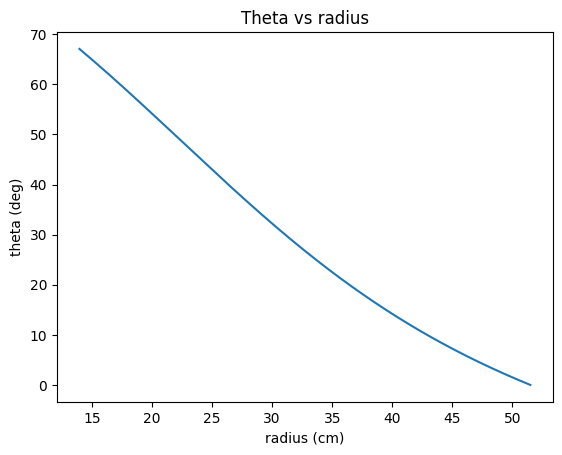

In [19]:
plt.figure()
plt.plot(cone_config["radius"] - real_y_position[::-1], np.rad2deg(theta))
plt.xlabel("radius (cm)")
plt.ylabel("theta (deg)")
plt.title("Theta vs radius")
plt.savefig("theta_vs_radius.png")
plt.savefig("theta_vs_radius.svg")
plt.show()

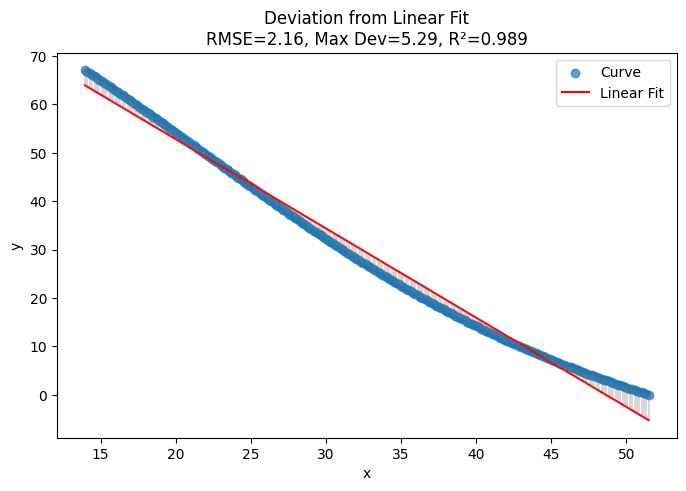

RMSE: 2.161
Max Deviation: 5.289
R²: 0.989


In [20]:
x = cone_config["radius"] - real_y_position[::-1]
y = np.rad2deg(theta)

# Fit a linear model (degree 1 polynomial)
coeffs = np.polyfit(x, y, 1)  # Linear fit: y = ax + b
linear_fit = np.polyval(coeffs, x)  # Evaluate the linear fit

# Compute residuals (deviation from linearity)
residuals = y - linear_fit
rmse = np.sqrt(np.mean(residuals**2))  # Root Mean Squared Error
max_dev = np.max(np.abs(residuals))  # Max deviation

# Compute R² (goodness of fit)
ss_tot = np.sum((y - np.mean(y))**2)
ss_res = np.sum(residuals**2)
r2 = 1 - (ss_res / ss_tot)

# Plot results
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Curve", alpha=0.7)
plt.plot(x, linear_fit, color='red', label="Linear Fit")
plt.vlines(x, linear_fit, y, color='gray', alpha=0.3)  # Show residuals
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Deviation from Linear Fit\nRMSE={rmse:.2f}, Max Dev={max_dev:.2f}, R²={r2:.3f}")
plt.savefig("deviation_from_linear_fit.png")
plt.savefig("deviation_from_linear_fit.svg")
plt.legend()
plt.show()

print(f"RMSE: {rmse:.3f}")
print(f"Max Deviation: {max_dev:.3f}")
print(f"R²: {r2:.3f}")
